In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset

df = pd.read_csv("database.csv")

# Display first 5 rows
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [3]:
# Check all values
print(df.isna())

        Date   Time  Latitude  Longitude   Type  Depth  Depth Error  \
0      False  False     False      False  False  False         True   
1      False  False     False      False  False  False         True   
2      False  False     False      False  False  False         True   
3      False  False     False      False  False  False         True   
4      False  False     False      False  False  False         True   
...      ...    ...       ...        ...    ...    ...          ...   
23407  False  False     False      False  False  False        False   
23408  False  False     False      False  False  False        False   
23409  False  False     False      False  False  False        False   
23410  False  False     False      False  False  False        False   
23411  False  False     False      False  False  False        False   

       Depth Seismic Stations  Magnitude  Magnitude Type  ...  \
0                        True      False           False  ...   
1                

In [4]:
print(df.isna().sum())

Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
dtype: int64


In [5]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [6]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (23412, 21) 

number of rows:  23412
number of columns:  21


In [7]:
# viewing the data types of columns
df.dtypes

Date                           object
Time                           object
Latitude                      float64
Longitude                     float64
Type                           object
Depth                         float64
Depth Error                   float64
Depth Seismic Stations        float64
Magnitude                     float64
Magnitude Type                 object
Magnitude Error               float64
Magnitude Seismic Stations    float64
Azimuthal Gap                 float64
Horizontal Distance           float64
Horizontal Error              float64
Root Mean Square              float64
ID                             object
Source                         object
Location Source                object
Magnitude Source               object
Status                         object
dtype: object

In [17]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
print(df['Date'].dtype)
df.dtypes

datetime64[ns]


Date                          datetime64[ns]
Time                                  object
Latitude                             float64
Longitude                            float64
Type                                  object
Depth                                float64
Depth Error                          float64
Depth Seismic Stations               float64
Magnitude                            float64
Magnitude Type                        object
Magnitude Error                      float64
Magnitude Seismic Stations           float64
Azimuthal Gap                        float64
Horizontal Distance                  float64
Horizontal Error                     float64
Root Mean Square                     float64
ID                                    object
Source                                object
Location Source                       object
Magnitude Source                      object
Status                                object
dtype: object

In [10]:
# Statistical summary
df.describe(include='all')

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
count,23412,23412,23412.000000,23412.000000,23412,23412.000000,4461.000000,7097.000000,23412.000000,23409,...,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000,23412,23412,23412,23412,23412
unique,12401,20472,NaN,NaN,4,NaN,NaN,NaN,NaN,10,...,NaN,NaN,NaN,NaN,NaN,23412,13,48,24,2
top,2011-03-11 00:00:00,02:56:58,NaN,NaN,Earthquake,NaN,NaN,NaN,NaN,MW,...,NaN,NaN,NaN,NaN,NaN,US10007NTD,US,US,US,Reviewed
freq,128,5,NaN,NaN,23232,NaN,NaN,NaN,NaN,7722,...,NaN,NaN,NaN,NaN,NaN,1,20630,20350,10458,20773
mean,NaN,NaN,1.679033,39.639961,NaN,70.767911,4.993115,275.364098,5.882531,NaN,...,48.944618,44.163532,3.992660,7.662759,1.022784,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,30.113183,125.511959,NaN,122.651898,4.875184,162.141631,0.423066,NaN,...,62.943106,32.141486,5.377262,10.430396,0.188545,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,-77.080000,-179.997000,NaN,-1.100000,0.000000,0.000000,5.500000,NaN,...,0.000000,0.000000,0.004505,0.085000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,-18.653000,-76.349750,NaN,14.522500,1.800000,146.000000,5.600000,NaN,...,10.000000,24.100000,0.968750,5.300000,0.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,-3.568500,103.982000,NaN,33.000000,3.500000,255.000000,5.700000,NaN,...,28.000000,36.000000,2.319500,6.700000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,26.190750,145.026250,NaN,54.000000,6.300000,384.000000,6.000000,NaN,...,66.000000,54.000000,4.724500,8.100000,1.130000,NaN,NaN,NaN,NaN,NaN


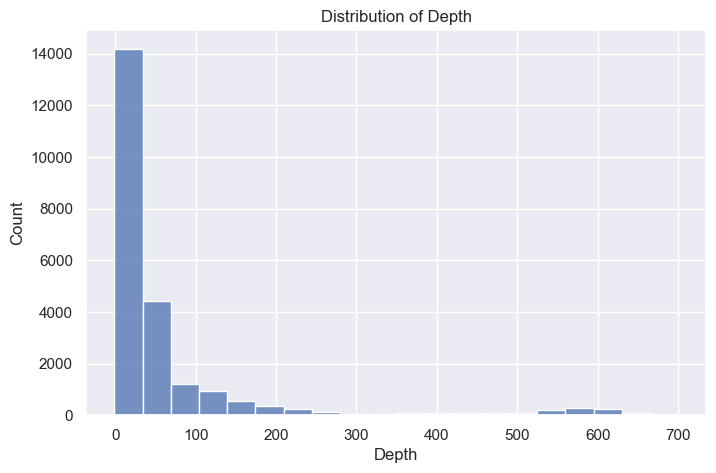

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Depth'], bins=20)
plt.title("Distribution of Depth")
plt.show()

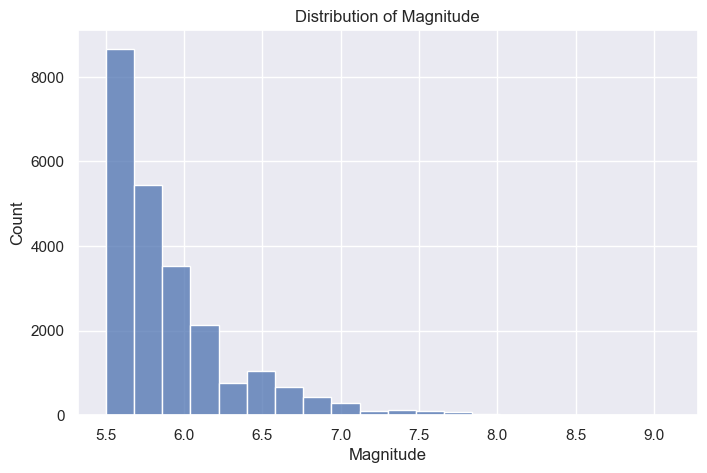

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Magnitude'], bins=20)
plt.title("Distribution of Magnitude")
plt.show()

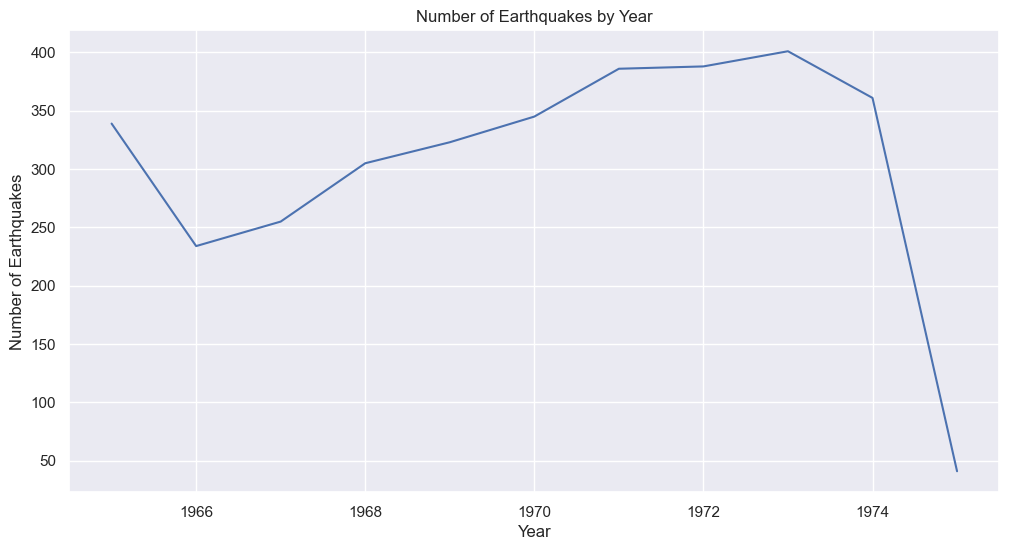

In [18]:

# Extract year
df['Year'] = df['Date'].dt.year

# Count earthquakes per year
year_counts = df['Year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12,6))
plt.plot(year_counts.index, year_counts.values)
plt.title('Number of Earthquakes by Year')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.grid(True)
plt.show()

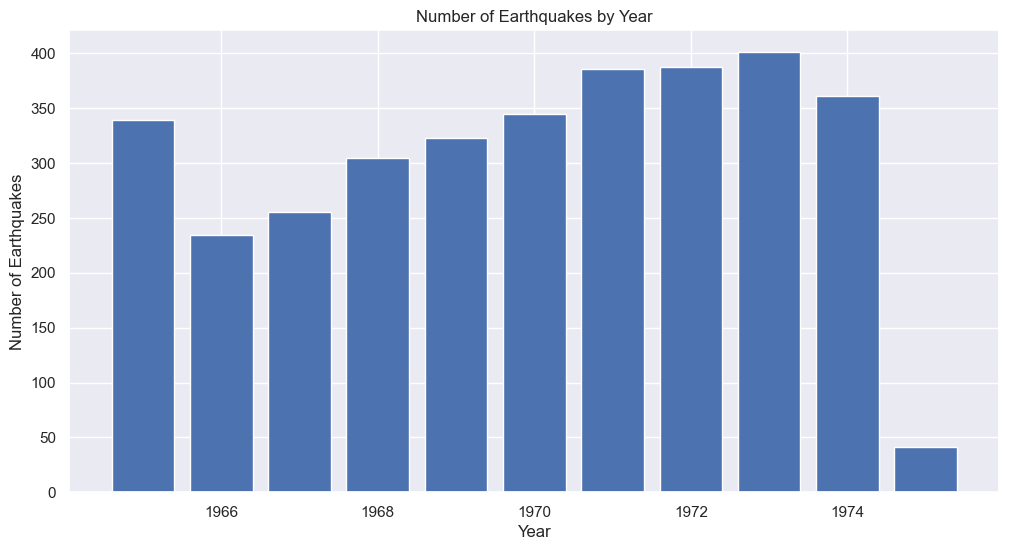

In [20]:
df['Year'] = df['Date'].dt.year

year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(year_counts.index, year_counts.values)
plt.title('Number of Earthquakes by Year')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.show()

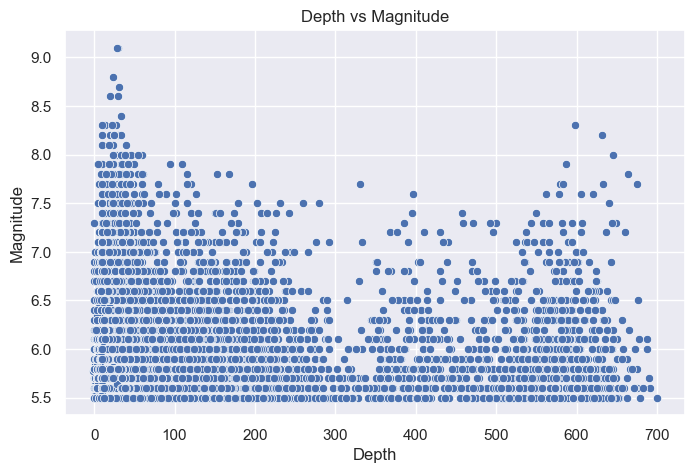

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Depth', y='Magnitude', data=df)
plt.title("Depth vs Magnitude")
plt.show()

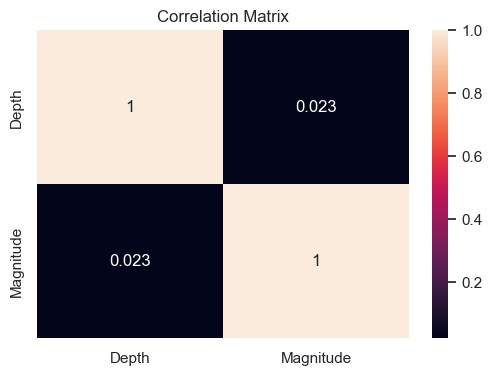

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Depth', 'Magnitude']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

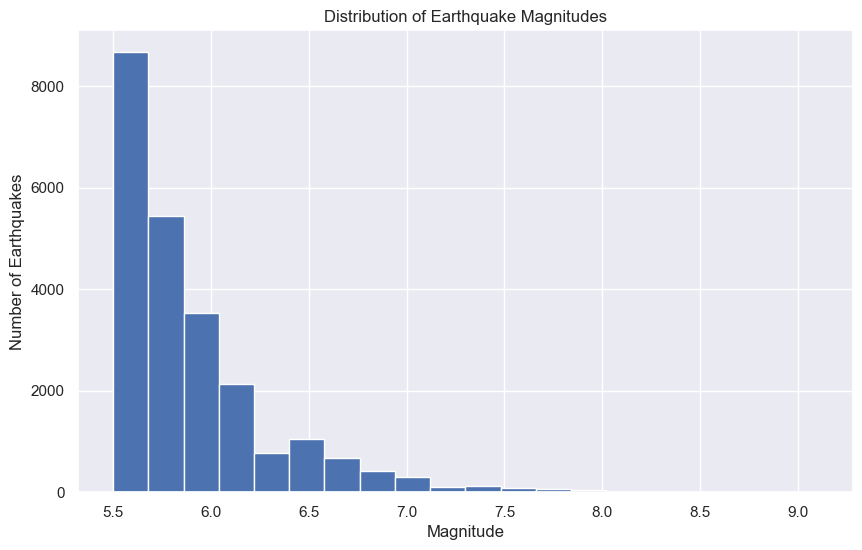

In [21]:
plt.figure(figsize=(10,6))
plt.hist(df['Magnitude'], bins=20)

plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Number of Earthquakes')

plt.show()

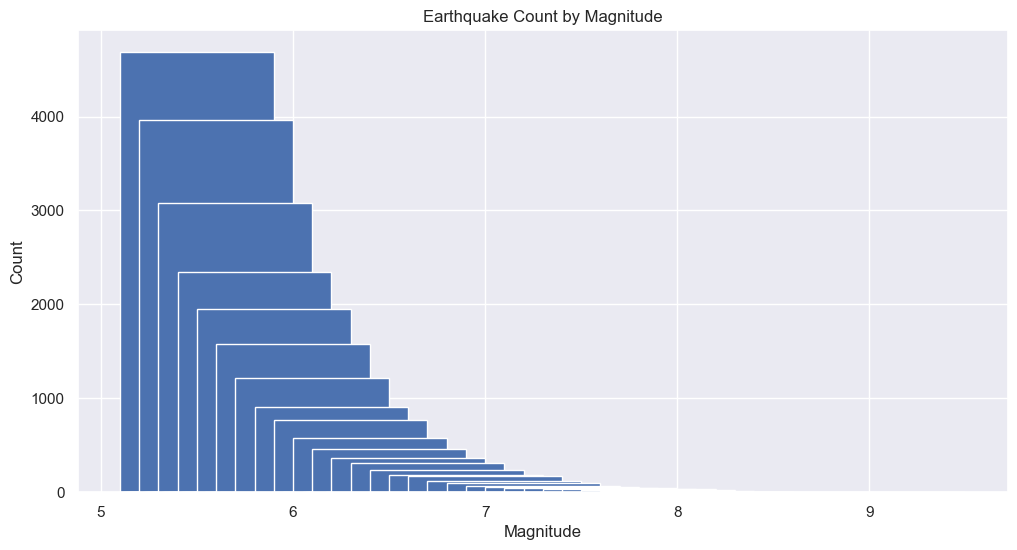

In [22]:
mag_counts = df['Magnitude'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(mag_counts.index, mag_counts.values)

plt.title('Earthquake Count by Magnitude')
plt.xlabel('Magnitude')
plt.ylabel('Count')

plt.show()